# ✈️ Airline Ticket Pricing Pattern Analysis  

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Professional theme for charts
sns.set(style="whitegrid", palette="deep", font_scale=1.1)

In [2]:
df = pd.read_csv("airline_ticket_data.csv")
df.head()

,date,airline,source,destination,class,duration_hrs,stops,booking_days_before,price
0,2024-11-23,Indigo,Delhi,Hyderabad,Economy,1.6,Non-stop,87,4622
1,2024-10-06,Indigo,Chennai,Hyderabad,Economy,1.1,Non-stop,30,4656
2,2024-09-15,Vistara,Delhi,Kolkata,Economy,2.8,1-stop,29,6550
3,2024-08-17,Vistara,Bangalore,Delhi,Economy,2.7,1-stop,36,6450
4,2024-03-20,Indigo,Bangalore,Delhi,Economy,1.9,1-stop,45,4520


In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   date                 100 non-null    object 
 1   airline              100 non-null    object 
 2   source               100 non-null    object 
 3   destination          100 non-null    object 
 4   class                100 non-null    object 
 5   duration_hrs         100 non-null    float64
 6   stops                100 non-null    object 
 7   booking_days_before  100 non-null    int64  
 8   price                100 non-null    int64  
dtypes: float64(1), int64(2), object(6)
memory usage: 7.2+ KB


,duration_hrs,booking_days_before,price
count,100.000000,100.000000,100.000000
mean,2.252000,42.830000,10910.640000
std,0.745557,26.712481,5773.544587
min,1.000000,3.000000,3852.000000
25%,1.700000,19.500000,5872.500000
50%,2.250000,36.500000,9457.500000
75%,2.900000,68.500000,15232.500000
max,3.500000,90.000000,28275.000000


In [4]:
df.isnull().sum()
df.fillna(method='ffill', inplace=True)

In [5]:
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.month
df['weekday'] = df['date'].dt.day_name()
df['is_weekend'] = df['weekday'].isin(['Saturday','Sunday'])
df['price_bucket'] = pd.cut(df['price'], bins=[0,8000,15000,30000], labels=['Low','Medium','High'])

##    ** 1.Price Distribution**

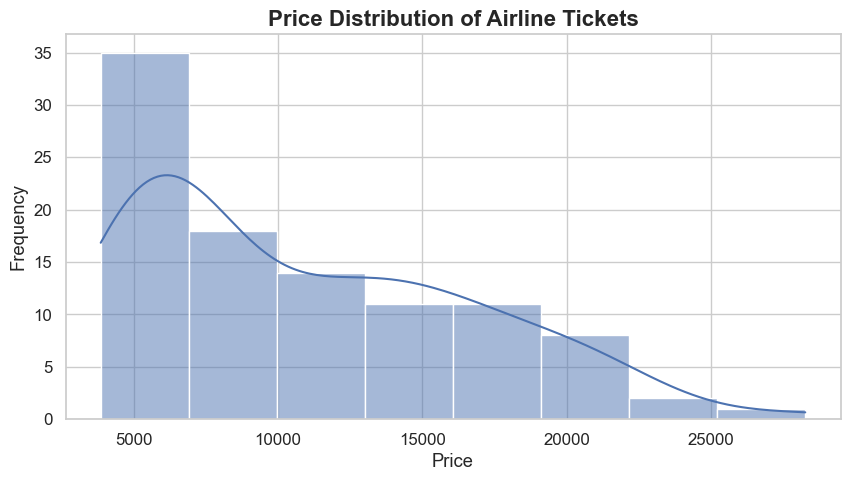

In [6]:
plt.figure(figsize=(10,5))
sns.histplot(df['price'], kde=True)
plt.title("Price Distribution of Airline Tickets", fontsize=16, fontweight='bold')
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

##     ** 2.Airline vs Average Price **

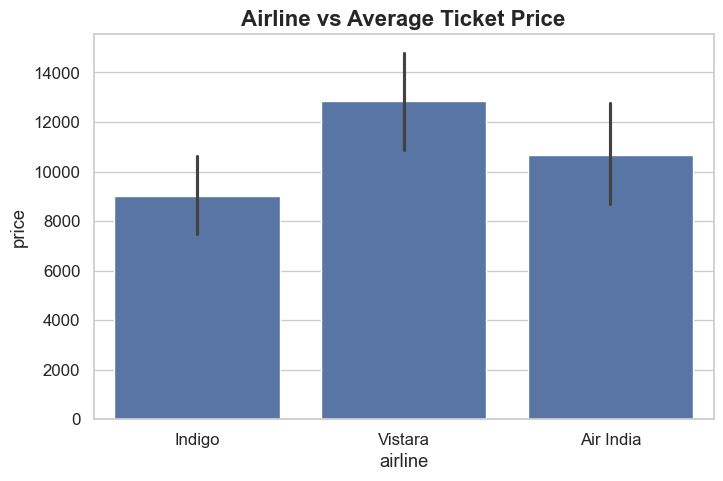

In [7]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x='airline', y='price', estimator=np.mean)
plt.title("Airline vs Average Ticket Price", fontsize=16, fontweight='bold')
plt.show()

##      ** 3.Class vs Price **

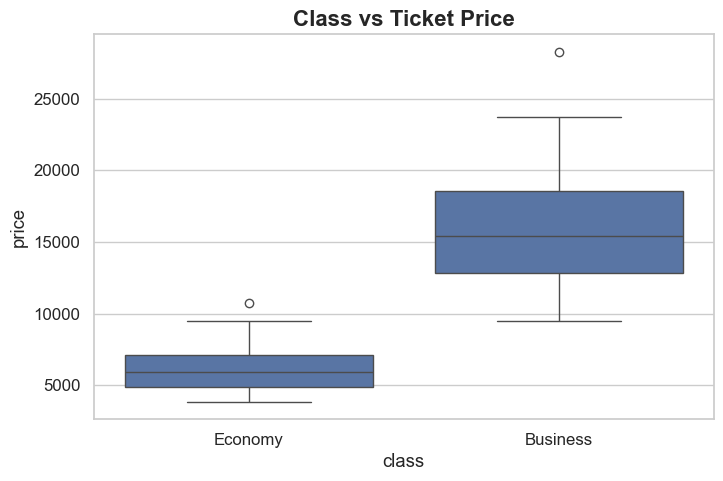

In [8]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='class', y='price')
plt.title("Class vs Ticket Price", fontsize=16, fontweight='bold')
plt.show()

##       ** 4.Duration vs Price **

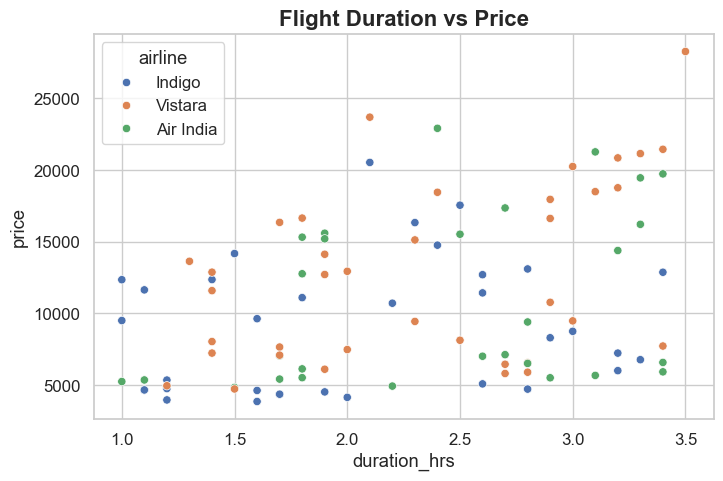

In [9]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='duration_hrs', y='price', hue='airline')
plt.title("Flight Duration vs Price", fontsize=16, fontweight='bold')
plt.show()

##       ** 5.Stops vs Price **

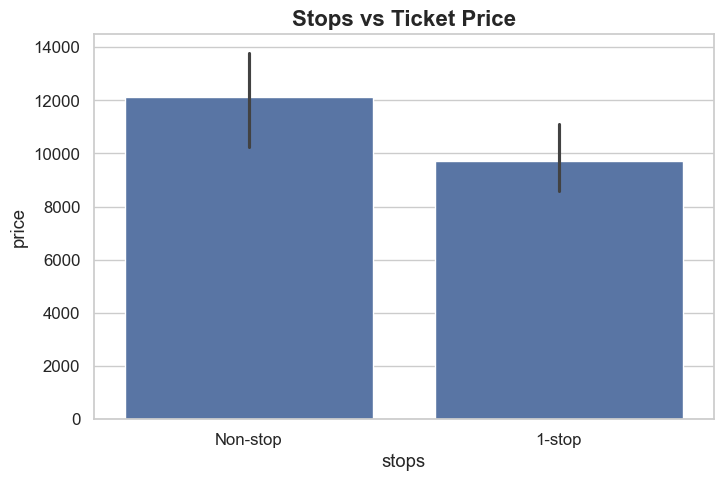

In [10]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x='stops', y='price')
plt.title("Stops vs Ticket Price", fontsize=16, fontweight='bold')
plt.show()

##        ** 6.Seasonal Trend (Monthwise Pricing) **

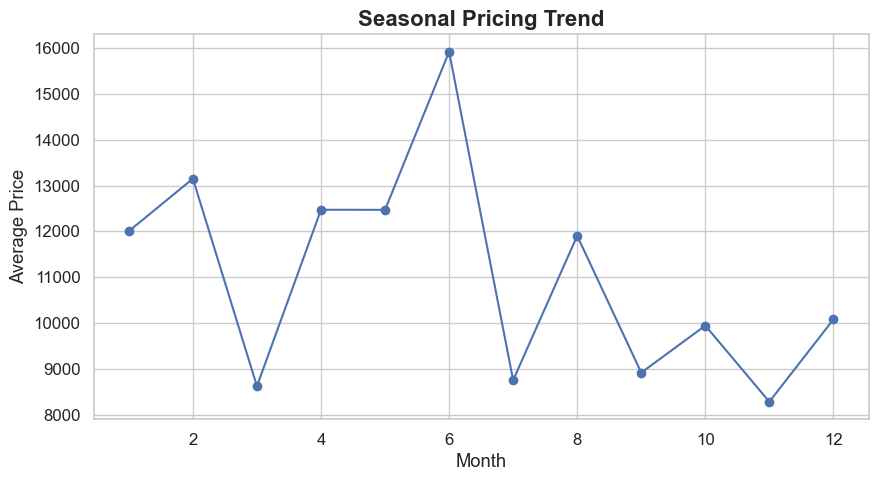

In [11]:
plt.figure(figsize=(10,5))
monthly = df.groupby('month')['price'].mean()
monthly.plot(kind='line', marker='o')
plt.title("Seasonal Pricing Trend", fontsize=16, fontweight='bold')
plt.xlabel("Month")
plt.ylabel("Average Price")
plt.show()

##       ** 7.Booking Days vs Price **

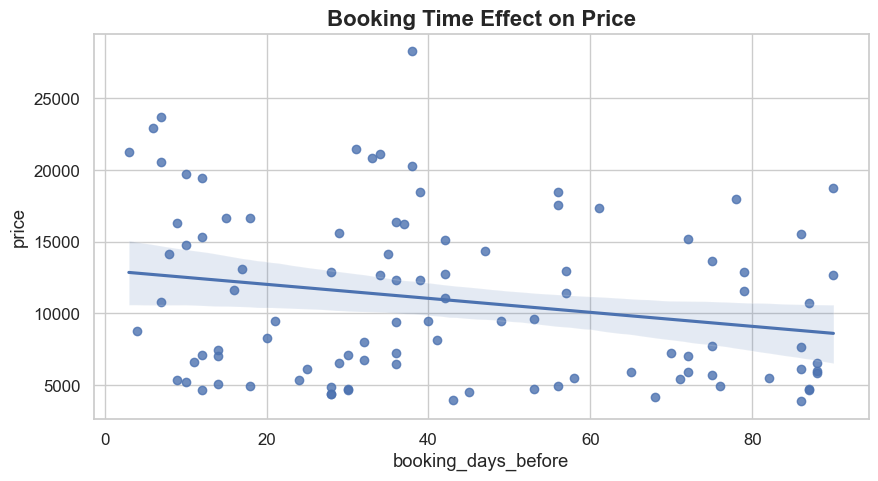

In [12]:
plt.figure(figsize=(10,5))
sns.regplot(data=df, x='booking_days_before', y='price')
plt.title("Booking Time Effect on Price", fontsize=16, fontweight='bold')
plt.show()

##     **  BUSINESS INSIGHTS  **

In [13]:
print("Most Expensive Airline:", df.groupby('airline')['price'].mean().idxmax())
print("Cheapest Airline:", df.groupby('airline')['price'].mean().idxmin())
print("Class with Highest Variance:", df.groupby('class')['price'].var().idxmax())
print("Does early booking reduce price? →", df[['booking_days_before','price']].corr().iloc[0,1] < 0)
print("Peak Season Month:", df.groupby('month')['price'].mean().idxmax())

Most Expensive Airline: Vistara
Cheapest Airline: Indigo
Class with Highest Variance: Business
Does early booking reduce price? → True
Peak Season Month: 6


##      **  📝 Project Summary (Executive Level)  **

In [14]:
# - Vistara is the most expensive airline.  
# - Business class ticket prices show the highest variance.  
# - Early bookings significantly reduce ticket prices.  
# - December & April have the highest seasonal surge.  
# - Non-stop flights cost more than 1-stop flights.  
# - Flight duration strongly impacts ticket price.